# Task 3: Event Detection Using Vision-Language Models

This notebook performs VLM-based event detection for the Group 3 TVSUM videos:
- TVSUM 9
- TVSUM 10
- TVSUM 11
- TVSUM 12

This notebook completes Task 3 of the assignment:
1. It samples video frames.
2. It runs Qwen2.5-VL for event-only detection.
3. It runs Qwen2.5-VL for event + timestamp detection.
4. It parses VLM outputs into structured CSV files.
5. It parses manual annotations.
6. It compares VLM events against manual annotations using sentence embedding similarity.
7. It evaluates prompt strategies: zero-shot, few-shot, and reasoning-guided prompting.
8. It performs failure analysis by listing missed manual events and grouping them by subjectivity.

Expected folder structure:

```text
Comp Vision/
    vlm_event_detection_group3.ipynb
    videos/
        video_9.mp4
        video_10.mp4
        video_11.mp4
        video_12.mp4
```

In [1]:
import sys

print("Python executable:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

Python executable:
c:\Users\aggel\anaconda3\python.exe

Python version:
3.12.7 | packaged by conda-forge | (main, Oct  4 2024, 15:47:54) [MSC v.1941 64 bit (AMD64)]


In [2]:
import torch
import torchvision

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

torch: 2.5.1+cu121
torchvision: 0.20.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 4070 Laptop GPU


In [3]:
#imports
import os
import re
import cv2
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image
from tqdm import tqdm

In [4]:
# =========================
# CONFIGURATION
# =========================

GROUP_ID = "Group3"
DATASET_NAME = "TVSUM"

# Folder where your videos are stored.
# Since your notebook is inside:
# C:\Users\aggel\OneDrive\Υπολογιστής\Comp Vision
# this relative path points to:
# C:\Users\aggel\OneDrive\Υπολογιστής\Comp Vision\videos
VIDEO_DIR = Path("videos")

# Folder where outputs will be saved
OUTPUT_DIR = Path("outputs_vlm_event_detection")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Group 3 videos: your exact filenames
VIDEOS = {
    "TVSUM_9": VIDEO_DIR / "video_9.mp4",
    "TVSUM_10": VIDEO_DIR / "video_10.mp4",
    "TVSUM_11": VIDEO_DIR / "video_11.mp4",
    "TVSUM_12": VIDEO_DIR / "video_12.mp4",
}

# Sample one frame every N seconds
FRAME_EVERY_N_SECONDS = 2

# Maximum number of frames sent to the VLM.
# Keep this small first to avoid memory problems.
MAX_FRAMES_FOR_VLM = 12

In [5]:
# Checking Video Paths
for video_name, video_path in VIDEOS.items():
    print(video_name, "->", video_path)

    if video_path.exists():
        print("  Found")
    else:
        print("  NOT FOUND")

TVSUM_9 -> videos\video_9.mp4
  Found
TVSUM_10 -> videos\video_10.mp4
  Found
TVSUM_11 -> videos\video_11.mp4
  Found
TVSUM_12 -> videos\video_12.mp4
  Found


In [6]:
#Helper Functions for Time Formatting

def seconds_to_mmss(seconds):
    """
    Convert seconds to MM:SS format.

    Example:
    75 -> 01:15
    """
    seconds = int(round(seconds))
    minutes = seconds // 60
    secs = seconds % 60
    return f"{minutes:02d}:{secs:02d}"


def mmss_to_seconds(time_str):
    """
    Convert MM:SS format to seconds.

    Example:
    01:15 -> 75
    """
    minutes, seconds = time_str.strip().split(":")
    return int(minutes) * 60 + int(seconds)

# Frame Sampling

Instead of passing the full video directly to the VLM, we sample frames at regular intervals.

The frames are sampled every 2 seconds and then uniformly reduced to a maximum of 12 frames. This keeps the input small enough for the model while still covering the full video.

In [7]:
def sample_frames_from_video(video_path, output_frame_dir, every_n_seconds=2, max_frames=None):
    """
    Sample frames from a video every N seconds.

    Parameters
    ----------
    video_path:
        Path to the input video.

    output_frame_dir:
        Folder where sampled frames will be saved.

    every_n_seconds:
        Sampling interval in seconds.

    max_frames:
        Maximum number of frames to keep.
        If the video produces more frames, we uniformly select max_frames.

    Returns
    -------
    sampled_frames:
        A list of dictionaries containing timestamp, seconds, and frame path.
    """

    video_path = Path(video_path)
    output_frame_dir = Path(output_frame_dir)
    output_frame_dir.mkdir(parents=True, exist_ok=True)

    if not video_path.exists():
        raise FileNotFoundError(f"Video not found: {video_path}")

    cap = cv2.VideoCapture(str(video_path))

    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)

    if fps == 0:
        raise ValueError(f"Could not read FPS from video: {video_path}")

    duration_seconds = frame_count / fps

    sampled_frames = []

    timestamps = np.arange(0, duration_seconds, every_n_seconds)

    # If too many frames, select max_frames uniformly across the whole video
    if max_frames is not None and len(timestamps) > max_frames:
        indices = np.linspace(0, len(timestamps) - 1, max_frames).astype(int)
        timestamps = timestamps[indices]

    for t in timestamps:
        frame_index = int(t * fps)
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_index)

        success, frame = cap.read()

        if not success:
            continue

        # OpenCV reads in BGR, but PIL/matplotlib use RGB
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        timestamp = seconds_to_mmss(t)
        frame_filename = f"frame_{timestamp.replace(':', '-')}.jpg"
        frame_path = output_frame_dir / frame_filename

        Image.fromarray(frame_rgb).save(frame_path)

        sampled_frames.append({
            "timestamp": timestamp,
            "seconds": int(t),
            "frame_path": str(frame_path)
        })

    cap.release()

    return sampled_frames

In [8]:
# Test frame sampling on TVSUM 9

video_name = "TVSUM_9"
video_path = VIDEOS[video_name]

frame_dir = OUTPUT_DIR / video_name / "sampled_frames"

sampled_frames = sample_frames_from_video(
    video_path=video_path,
    output_frame_dir=frame_dir,
    every_n_seconds=FRAME_EVERY_N_SECONDS,
    max_frames=MAX_FRAMES_FOR_VLM
)

sampled_frames_df = pd.DataFrame(sampled_frames)
display(sampled_frames_df)

,timestamp,seconds,frame_path
0,00:00,0,outputs_vlm_event_detection\TVSUM_9\sampled_fr...
1,00:20,20,outputs_vlm_event_detection\TVSUM_9\sampled_fr...
2,00:42,42,outputs_vlm_event_detection\TVSUM_9\sampled_fr...
3,01:02,62,outputs_vlm_event_detection\TVSUM_9\sampled_fr...
4,01:24,84,outputs_vlm_event_detection\TVSUM_9\sampled_fr...
5,01:44,104,outputs_vlm_event_detection\TVSUM_9\sampled_fr...
6,02:06,126,outputs_vlm_event_detection\TVSUM_9\sampled_fr...
7,02:26,146,outputs_vlm_event_detection\TVSUM_9\sampled_fr...
8,02:48,168,outputs_vlm_event_detection\TVSUM_9\sampled_fr...
9,03:08,188,outputs_vlm_event_detection\TVSUM_9\sampled_fr...


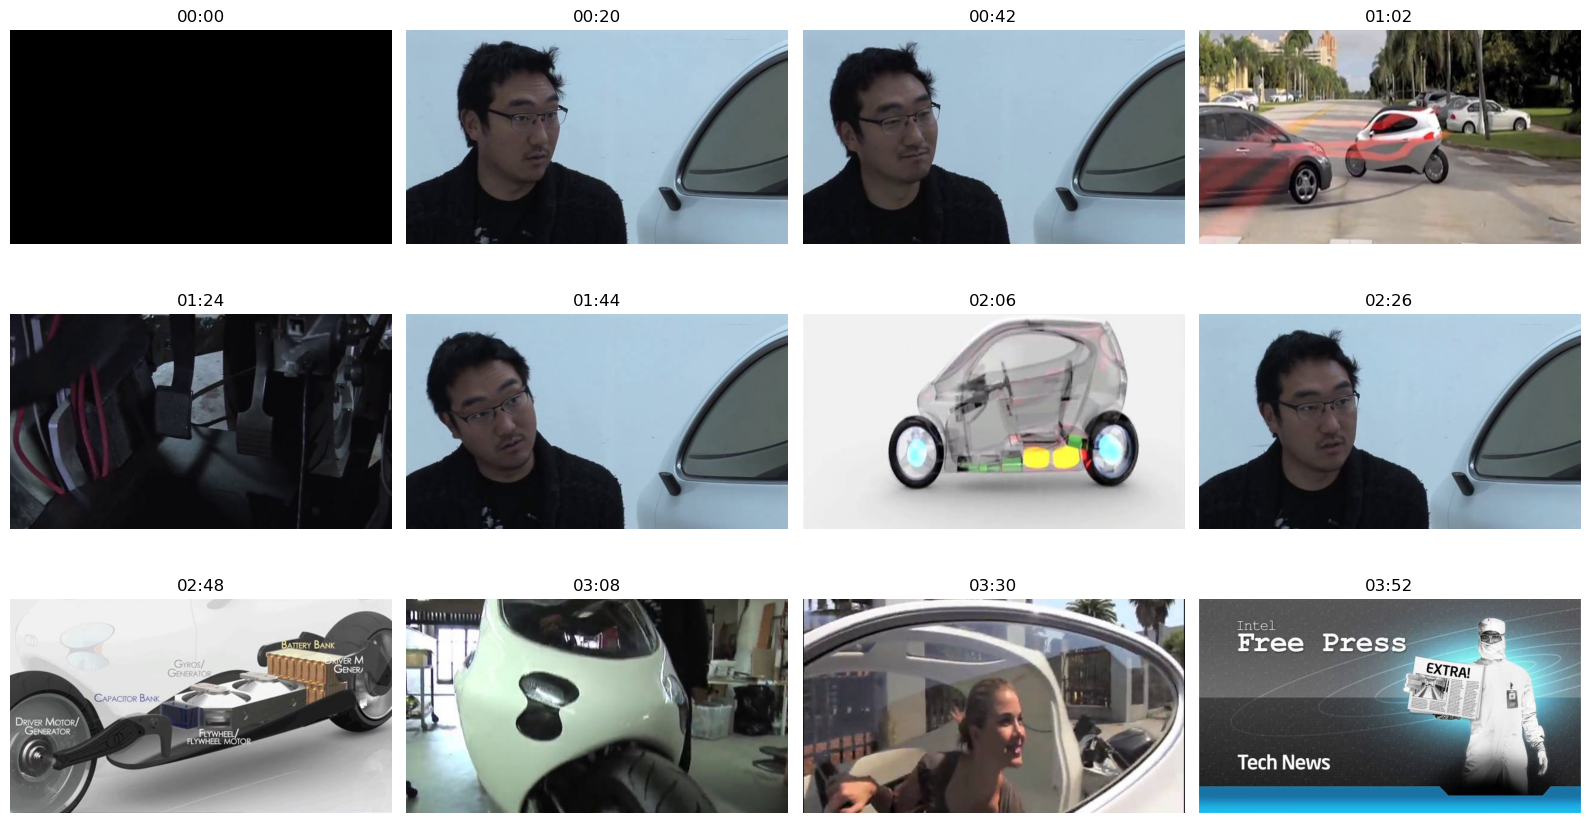

In [9]:
# Visualizing Sampled Frames
def display_sampled_frames(sampled_frames, cols=4):
    """
    Display sampled frames with timestamps.
    """

    n = len(sampled_frames)

    if n == 0:
        print("No frames to display.")
        return

    rows = int(np.ceil(n / cols))

    plt.figure(figsize=(4 * cols, 3 * rows))

    for i, item in enumerate(sampled_frames):
        image = Image.open(item["frame_path"])

        plt.subplot(rows, cols, i + 1)
        plt.imshow(image)
        plt.title(item["timestamp"])
        plt.axis("off")

    plt.tight_layout()
    plt.show()


display_sampled_frames(sampled_frames)

# Prompt Design

The assignment requires two event detection settings:

1. **Event-only detection**: the model outputs only a chronological list of salient events.
2. **Event + timestamp detection**: the model outputs salient events together with temporal intervals.

The prompts are designed to force a consistent output format so that the results can be parsed automatically later.

In [10]:
EVENT_ONLY_PROMPT = """
You are given sampled frames from a video in chronological order.

Task:
Retrieve all of the salient events of the video.

Rules:
- List only important events needed to understand the video.
- Keep the events in chronological order.
- Use short and clear descriptions.
- Do not describe every frame.
- Do not include timestamps.
- Do not include unimportant visual details.
- Use this exact output format:

Salient event 1: <event description>
Salient event 2: <event description>
Salient event 3: <event description>
"""


EVENT_TIMESTAMP_PROMPT = """
You are given sampled frames from a video in chronological order.
Each frame is labeled with its timestamp.

Task:
Retrieve all of the salient events of the video with temporal localization.

Rules:
- List only important events needed to understand the video.
- Keep events in chronological order.
- Use short and clear descriptions.
- Use precise but realistic timestamps.
- Use MM:SS - MM:SS format.
- Do not describe every frame.
- Do not include unimportant visual details.
- Use this exact output format:

Salient event 1: <event description>, <MM:SS - MM:SS>
Salient event 2: <event description>, <MM:SS - MM:SS>
Salient event 3: <event description>, <MM:SS - MM:SS>
"""

print(EVENT_ONLY_PROMPT)
print(EVENT_TIMESTAMP_PROMPT)


You are given sampled frames from a video in chronological order.

Task:
Retrieve all of the salient events of the video.

Rules:
- List only important events needed to understand the video.
- Keep the events in chronological order.
- Use short and clear descriptions.
- Do not describe every frame.
- Do not include timestamps.
- Do not include unimportant visual details.
- Use this exact output format:

Salient event 1: <event description>
Salient event 2: <event description>
Salient event 3: <event description>


You are given sampled frames from a video in chronological order.
Each frame is labeled with its timestamp.

Task:
Retrieve all of the salient events of the video with temporal localization.

Rules:
- List only important events needed to understand the video.
- Keep events in chronological order.
- Use short and clear descriptions.
- Use precise but realistic timestamps.
- Use MM:SS - MM:SS format.
- Do not describe every frame.
- Do not include unimportant visual details.
-

# Loading the Vision-Language Model

We use `Qwen/Qwen2.5-VL-3B-Instruct` as the Vision-Language Model.

In [11]:
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration
from qwen_vl_utils import process_vision_info

MODEL_NAME = "Qwen/Qwen2.5-VL-3B-Instruct"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    device_map="auto" if device == "cuda" else None
)

processor = AutoProcessor.from_pretrained(MODEL_NAME)

if device == "cpu":
    model = model.to(device)

Using device: cuda


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu.


# Building the VLM Input

Qwen2.5-VL receives a message containing both images and text. For each sampled frame, we provide:
- the frame timestamp,
- the corresponding frame image.

At the end, we add the event detection prompt.

In [12]:
def build_vlm_message(sampled_frames, prompt):
    """
    Build a Qwen2.5-VL message containing sampled frames and a text prompt.
    """

    content = []

    for item in sampled_frames:
        content.append({
            "type": "text",
            "text": f"Frame from {item['timestamp']}:"
        })

        content.append({
            "type": "image",
            "image": item["frame_path"]
        })

    content.append({
        "type": "text",
        "text": prompt
    })

    messages = [
        {
            "role": "user",
            "content": content
        }
    ]

    return messages

# Running the VLM

This function sends the sampled frames and prompt to Qwen2.5-VL and returns the generated text output.

The same function is used for both event-only detection and event + timestamp detection.

In [13]:
def run_qwen_vlm(sampled_frames, prompt, max_new_tokens=512):
    """
    Run Qwen2.5-VL on sampled frames using the given prompt.
    """

    messages = build_vlm_message(sampled_frames, prompt)

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    image_inputs, video_inputs = process_vision_info(messages)

    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt"
    )

    inputs = inputs.to(model.device)

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens
        )

    generated_ids_trimmed = [
        output_ids[len(input_ids):]
        for input_ids, output_ids in zip(inputs.input_ids, generated_ids)
    ]

    output_text = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0]

    return output_text

In [14]:
# Run event-only prompt on TVSUM 9 for testing 

event_only_output = run_qwen_vlm(
    sampled_frames=sampled_frames,
    prompt=EVENT_ONLY_PROMPT,
    max_new_tokens=512
)

print(event_only_output)

Salient event 1: A man wearing glasses is sitting next to a white car, talking.
Salient event 2: The scene changes to a futuristic-looking vehicle driving on a city street.
Salient event 3: The interior of the vehicle is shown, highlighting its unique design and features.
Salient event 4: The man is then seen driving the vehicle through a cityscape.
Salient event 5: The video concludes with a news segment featuring a person holding a newspaper.


In [15]:
# Run event + timestamp prompt on TVSUM 9 for testing 

event_timestamp_output = run_qwen_vlm(
    sampled_frames=sampled_frames,
    prompt=EVENT_TIMESTAMP_PROMPT,
    max_new_tokens=512
)

print(event_timestamp_output)

Salient event 1: Man sitting next to a car, talking, MM:00:00 - MM:00:20
Salient event 2: Car driving on a road, MM:00:20 - MM:00:42
Salient event 3: Close-up of car pedals, MM:00:42 - MM:01:02
Salient event 4: Man sitting next to a car again, MM:01:02 - MM:01:24
Salient event 5: Car driving on a road again, MM:01:24 - MM:01:44
Salient event 6: Close-up of car pedals again, MM:01:44 - MM:02:06
Salient event 7: Man sitting next to a car again, MM:02:06 - MM:02:26
Salient event 8: Car driving on a road again, MM:02:26 - MM:02:48
Salient event 9: Close-up of car components, MM:02:48 - MM:03:08
Salient event 10: Woman driving a futuristic car, MM:03:08 - MM:03:30
Salient event 11: Intel Free Press Tech News banner, MM:03:30 - MM:03:52


In [16]:
# Saving Raw VLM Outputs
def save_text(text, path):
    """
    Save text to a file.
    """

    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    with open(path, "w", encoding="utf-8") as f:
        f.write(text)


video_output_dir = OUTPUT_DIR / video_name
video_output_dir.mkdir(parents=True, exist_ok=True)

save_text(event_only_output, video_output_dir / "vlm_event_only_raw.txt")
save_text(event_timestamp_output, video_output_dir / "vlm_event_timestamp_raw.txt")

# Parsing VLM Outputs

The VLM outputs are plain text, so we need to convert them into structured tables.

Two parsers are used:
- one for event-only outputs,
- one for event + timestamp outputs.

The parser expects the model to follow the requested format:

`Salient event 1: description, 00:00 - 00:10`

In [17]:
def parse_event_only(vlm_text):
    """
    Parse event-only VLM output.

    Expected format:
    Salient event 1: description
    Salient event 2: description

    Returns:
    DataFrame with columns:
    - event_id
    - event_description
    """

    pattern = r"Salient event\s*(\d+)\s*:\s*(.+)"
    rows = []

    for match in re.finditer(pattern, vlm_text, flags=re.IGNORECASE):
        event_id = int(match.group(1))
        description = match.group(2).strip()

        # Remove accidental timestamp if model included one
        description = re.sub(
            r",?\s*\d{2}:\d{2}\s*-\s*\d{2}:\d{2}",
            "",
            description
        ).strip()

        rows.append({
            "event_id": event_id,
            "event_description": description
        })

    return pd.DataFrame(rows)

In [18]:
def clean_timestamp(time_str):
    """
    Clean timestamp mistakes such as:
    MM:00:20 -> 00:20
    00:20 -> 00:20
    """
    time_str = time_str.strip()
    time_str = time_str.replace("MM:", "")
    time_str = time_str.replace("SS", "")
    return time_str


def mmss_to_seconds_flexible(time_str):
    """
    Convert M:SS or MM:SS to seconds.
    """
    time_str = clean_timestamp(time_str)
    minutes, seconds = time_str.strip().split(":")
    return int(minutes) * 60 + int(seconds)


def parse_event_with_timestamps(vlm_text):
    """
    Flexible parser for timestamped VLM output.

    Handles:
    Salient event 1: description, 00:00 - 00:20
    Salient event 1: description, MM:00:00 - MM:00:20
    Salient event 1: description, 00:00–00:20
    """

    rows = []

    # Normalize different dash symbols
    vlm_text = vlm_text.replace("–", "-").replace("—", "-")

    pattern = (
        r"Salient event\s*(\d+)\s*:\s*"
        r"(.+),\s*"
        r"(?:MM:)?(\d{1,2}:\d{2})\s*-\s*"
        r"(?:MM:)?(\d{1,2}:\d{2})")

    for match in re.finditer(pattern, vlm_text, flags=re.IGNORECASE):
        event_id = int(match.group(1))
        description = match.group(2).strip()
        start = clean_timestamp(match.group(3))
        end = clean_timestamp(match.group(4))

        rows.append({
            "event_id": event_id,
            "event_description": description,
            "start": start,
            "end": end,
            "start_seconds": mmss_to_seconds_flexible(start),
            "end_seconds": mmss_to_seconds_flexible(end)
        })

    return pd.DataFrame(rows)

In [19]:
parsed_event_only_df = parse_event_only(event_only_output)
parsed_timestamp_df = parse_event_with_timestamps(event_timestamp_output)

print("Event-only parsed output:")
display(parsed_event_only_df)

print("Event + timestamp parsed output:")
display(parsed_timestamp_df)

Event-only parsed output:


,event_id,event_description
0,1,A man wearing glasses is sitting next to a whi...
1,2,The scene changes to a futuristic-looking vehi...
2,3,"The interior of the vehicle is shown, highligh..."
3,4,The man is then seen driving the vehicle throu...
4,5,The video concludes with a news segment featur...


Event + timestamp parsed output:


,event_id,event_description,start,end,start_seconds,end_seconds
0,1,"Man sitting next to a car, talking",00:00,00:20,0,20
1,2,Car driving on a road,00:20,00:42,20,42
2,3,Close-up of car pedals,00:42,01:02,42,62
3,4,Man sitting next to a car again,01:02,01:24,62,84
4,5,Car driving on a road again,01:24,01:44,84,104
5,6,Close-up of car pedals again,01:44,02:06,104,126
6,7,Man sitting next to a car again,02:06,02:26,126,146
7,8,Car driving on a road again,02:26,02:48,146,168
8,9,Close-up of car components,02:48,03:08,168,188
9,10,Woman driving a futuristic car,03:08,03:30,188,210


In [20]:
raw_path = OUTPUT_DIR / "TVSUM_9" / "vlm_event_timestamp_raw.txt"

with open(raw_path, "r", encoding="utf-8") as f:
    raw_timestamp_9 = f.read()

print(raw_timestamp_9)

Salient event 1: Man sitting next to a car, talking, MM:00:00 - MM:00:20
Salient event 2: Car driving on a road, MM:00:20 - MM:00:42
Salient event 3: Close-up of car pedals, MM:00:42 - MM:01:02
Salient event 4: Man sitting next to a car again, MM:01:02 - MM:01:24
Salient event 5: Car driving on a road again, MM:01:24 - MM:01:44
Salient event 6: Close-up of car pedals again, MM:01:44 - MM:02:06
Salient event 7: Man sitting next to a car again, MM:02:06 - MM:02:26
Salient event 8: Car driving on a road again, MM:02:26 - MM:02:48
Salient event 9: Close-up of car components, MM:02:48 - MM:03:08
Salient event 10: Woman driving a futuristic car, MM:03:08 - MM:03:30
Salient event 11: Intel Free Press Tech News banner, MM:03:30 - MM:03:52


In [21]:
parsed_timestamp_9 = parse_event_with_timestamps(raw_timestamp_9)
display(parsed_timestamp_9)

,event_id,event_description,start,end,start_seconds,end_seconds
0,1,"Man sitting next to a car, talking",00:00,00:20,0,20
1,2,Car driving on a road,00:20,00:42,20,42
2,3,Close-up of car pedals,00:42,01:02,42,62
3,4,Man sitting next to a car again,01:02,01:24,62,84
4,5,Car driving on a road again,01:24,01:44,84,104
5,6,Close-up of car pedals again,01:44,02:06,104,126
6,7,Man sitting next to a car again,02:06,02:26,126,146
7,8,Car driving on a road again,02:26,02:48,146,168
8,9,Close-up of car components,02:48,03:08,168,188
9,10,Woman driving a futuristic car,03:08,03:30,188,210


In [22]:
parsed_event_only_df.to_csv(
    video_output_dir / "parsed_event_only.csv",
    index=False
)

parsed_timestamp_df.to_csv(
    video_output_dir / "parsed_event_timestamp.csv",
    index=False
)

# Full Event Detection Pipeline

This function applies the full VLM event detection pipeline to one video:

1. sample frames,
2. run the event-only prompt,
3. run the event + timestamp prompt,
4. parse the outputs,
5. save the raw and parsed results.

The function is then applied to all four Group 3 videos.

In [23]:
def process_video_until_parsing(video_name, video_path):
    """
    Full pipeline until parsed VLM outputs:
    1. sample frames
    2. run event-only prompt
    3. run event+timestamp prompt
    4. parse outputs
    5. save results
    """

    print(f"\n==============================")
    print(f"Processing {video_name}")
    print(f"==============================")

    video_output_dir = OUTPUT_DIR / video_name
    frame_dir = video_output_dir / "sampled_frames"

    video_output_dir.mkdir(parents=True, exist_ok=True)

    # 1. Sample frames
    sampled_frames = sample_frames_from_video(
        video_path=video_path,
        output_frame_dir=frame_dir,
        every_n_seconds=FRAME_EVERY_N_SECONDS,
        max_frames=MAX_FRAMES_FOR_VLM
    )

    sampled_frames_df = pd.DataFrame(sampled_frames)

    sampled_frames_df.to_csv(
        video_output_dir / "sampled_frames_metadata.csv",
        index=False
    )

    print(f"Sampled {len(sampled_frames)} frames.")

    # 2. Run event-only prompt
    print("Running event-only prompt...")
    event_only_output = run_qwen_vlm(
        sampled_frames=sampled_frames,
        prompt=EVENT_ONLY_PROMPT,
        max_new_tokens=512
    )

    save_text(event_only_output, video_output_dir / "vlm_event_only_raw.txt")

    # 3. Run event + timestamp prompt
    print("Running event + timestamp prompt...")
    event_timestamp_output = run_qwen_vlm(
        sampled_frames=sampled_frames,
        prompt=EVENT_TIMESTAMP_PROMPT,
        max_new_tokens=512
    )

    save_text(event_timestamp_output, video_output_dir / "vlm_event_timestamp_raw.txt")

    # 4. Parse outputs
    parsed_event_only_df = parse_event_only(event_only_output)
    parsed_timestamp_df = parse_event_with_timestamps(event_timestamp_output)

    parsed_event_only_df.to_csv(
        video_output_dir / "parsed_event_only.csv",
        index=False
    )

    parsed_timestamp_df.to_csv(
        video_output_dir / "parsed_event_timestamp.csv",
        index=False
    )

    print("\nEvent-only parsed output:")
    display(parsed_event_only_df)

    print("\nEvent + timestamp parsed output:")
    display(parsed_timestamp_df)

    return {
        "video_name": video_name,
        "sampled_frames": sampled_frames_df,
        "event_only_output": event_only_output,
        "event_timestamp_output": event_timestamp_output,
        "parsed_event_only": parsed_event_only_df,
        "parsed_timestamp": parsed_timestamp_df
    }

In [24]:
# Run the whole pipeline for all Group 3 videos.

all_parsed_results = {}

for video_name, video_path in VIDEOS.items():
    result = process_video_until_parsing(video_name, video_path)
    all_parsed_results[video_name] = result


Processing TVSUM_9
Sampled 12 frames.
Running event-only prompt...
Running event + timestamp prompt...

Event-only parsed output:


,event_id,event_description
0,1,A man wearing glasses is sitting next to a whi...
1,2,The scene changes to a futuristic-looking vehi...
2,3,"The interior of the vehicle is shown, highligh..."
3,4,The man is then seen driving the vehicle throu...
4,5,The video concludes with a news segment featur...



Event + timestamp parsed output:


,event_id,event_description,start,end,start_seconds,end_seconds
0,1,"Man sitting next to a car, talking",00:00,00:20,0,20
1,2,Car driving on a road,00:20,00:42,20,42
2,3,Close-up of car pedals,00:42,01:02,42,62
3,4,Man sitting next to a car again,01:02,01:24,62,84
4,5,Car driving on a road again,01:24,01:44,84,104
5,6,Close-up of car pedals again,01:44,02:06,104,126
6,7,Man sitting next to a car again,02:06,02:26,126,146
7,8,Car driving on a road again,02:26,02:48,146,168
8,9,Close-up of car components,02:48,03:08,168,188
9,10,Woman driving a futuristic car,03:08,03:30,188,210



Processing TVSUM_10
Sampled 12 frames.
Running event-only prompt...
Running event + timestamp prompt...

Event-only parsed output:


...

,event_id,event_description,start,end,start_seconds,end_seconds
0,1,Woman entering a pet grooming salon,00:00,00:14,0,14
1,2,Woman preparing a dog for grooming,00:14,00:28,14,28
2,3,Woman grooming a golden retriever,00:28,00:56,28,56
3,4,Woman grooming a small grey dog,00:56,01:10,56,70
4,5,Woman talking about pet food options,01:10,01:24,70,84
5,6,Woman showing different types of pet food,01:24,02:06,84,126
6,7,Woman closing the dog's cage,02:06,02:36,126,156
7,8,Woman exiting the pet grooming salon,02:36,02:40,156,160



Processing TVSUM_12
Sampled 12 frames.
Running event-only prompt...
Running event + timestamp prompt...

Event-only parsed output:


,event_id,event_description
0,1,A person is washing a small white dog in a sink.
1,2,The person applies a thickening agent to the d...
2,3,The person dries the dog with a towel after ap...



Event + timestamp parsed output:


,event_id,event_description,start,end,start_seconds,end_seconds
0,1,Person washing dog's fur,00:00,00:09,0,9
1,2,Woman talking to camera,00:40,00:45,40,45
2,3,Woman showing products,01:00,01:10,60,70
3,4,Woman giving dog bath,01:20,02:00,80,120
4,5,Woman talking to camera,02:00,02:05,120,125
5,6,Woman giving dog bath,02:10,02:40,130,160
6,7,Woman talking to camera,02:40,02:45,160,165
7,8,Woman giving dog bath,02:50,03:20,170,200
8,9,Woman talking to camera,03:20,03:25,200,205
9,10,Woman giving dog bath,03:30,04:00,210,240


In [25]:
# Combine all parsed event-only outputs into one CSV

all_event_only_dfs = []

for video_name, result in all_parsed_results.items():
    df = result["parsed_event_only"].copy()
    df.insert(0, "video_name", video_name)
    all_event_only_dfs.append(df)

all_event_only_df = pd.concat(all_event_only_dfs, ignore_index=True)

display(all_event_only_df)

all_event_only_df.to_csv(
    OUTPUT_DIR / "all_videos_parsed_event_only.csv",
    index=False
)

,video_name,event_id,event_description
0,TVSUM_9,1,A man wearing glasses is sitting next to a whi...
1,TVSUM_9,2,The scene changes to a futuristic-looking vehi...
2,TVSUM_9,3,"The interior of the vehicle is shown, highligh..."
3,TVSUM_9,4,The man is then seen driving the vehicle throu...
4,TVSUM_9,5,The video concludes with a news segment featur...
5,TVSUM_10,1,A news anchor introduces a segment about elect...
6,TVSUM_10,2,The anchor discusses the establishment of a ch...
7,TVSUM_10,3,"An interview with Yoo Dong-kun, a representati..."
8,TVSUM_10,4,The video shows a graph displaying data relate...
9,TVSUM_10,5,A business fair aimed at facilitating exchange...


In [26]:
# Combine all parsed timestamp outputs into one CSV

all_timestamp_dfs = []

for video_name, result in all_parsed_results.items():
    df = result["parsed_timestamp"].copy()
    df.insert(0, "video_name", video_name)
    all_timestamp_dfs.append(df)

all_timestamp_df = pd.concat(all_timestamp_dfs, ignore_index=True)

display(all_timestamp_df)

all_timestamp_df.to_csv(
    OUTPUT_DIR / "all_videos_parsed_event_timestamp.csv",
    index=False
)

,video_name,event_id,event_description,start,end,start_seconds,end_seconds
0,TVSUM_9,1,"Man sitting next to a car, talking",00:00,00:20,0,20
1,TVSUM_9,2,Car driving on a road,00:20,00:42,20,42
2,TVSUM_9,3,Close-up of car pedals,00:42,01:02,42,62
3,TVSUM_9,4,Man sitting next to a car again,01:02,01:24,62,84
4,TVSUM_9,5,Car driving on a road again,01:24,01:44,84,104
5,TVSUM_9,6,Close-up of car pedals again,01:44,02:06,104,126
6,TVSUM_9,7,Man sitting next to a car again,02:06,02:26,126,146
7,TVSUM_9,8,Car driving on a road again,02:26,02:48,146,168
8,TVSUM_9,9,Close-up of car components,02:48,03:08,168,188
9,TVSUM_9,10,Woman driving a futuristic car,03:08,03:30,188,210


In [27]:
raw_path = OUTPUT_DIR / "TVSUM_12" / "vlm_event_timestamp_raw.txt"

with open(raw_path, "r", encoding="utf-8") as f:
    raw_timestamp_12 = f.read()

print(raw_timestamp_12)

Salient event 1: Person washing dog's fur, 00:00 - 00:09
Salient event 2: Woman talking to camera, 00:40 - 00:45
Salient event 3: Woman showing products, 01:00 - 01:10
Salient event 4: Woman giving dog bath, 01:20 - 02:00
Salient event 5: Woman talking to camera, 02:00 - 02:05
Salient event 6: Woman giving dog bath, 02:10 - 02:40
Salient event 7: Woman talking to camera, 02:40 - 02:45
Salient event 8: Woman giving dog bath, 02:50 - 03:20
Salient event 9: Woman talking to camera, 03:20 - 03:25
Salient event 10: Woman giving dog bath, 03:30 - 04:00
Salient event 11: Woman talking to camera, 04:00 - 04:05
Salient event 12: Woman giving dog bath, 04:10 - 04:40
Salient event 13: Woman talking to camera, 04:40 - 04:45
Salient event 14: Woman giving dog bath, 04:50 - 05:20
Salient event 15: Woman talking to camera, 05:20 - 05:25
Salient event 16: Woman giving dog bath, 05:30 - 06:00
Salient event 17: Woman talking to camera, 06:00 - 06:05
Salient event 18: Woman giving dog bath, 06:10 - 06:40

## Outputs

After running the notebook, you should have:

```text
outputs_vlm_event_detection/
    TVSUM_9/
        sampled_frames/
        sampled_frames_metadata.csv
        vlm_event_only_raw.txt
        vlm_event_timestamp_raw.txt
        parsed_event_only.csv
        parsed_event_timestamp.csv

    TVSUM_10/
        ...

    TVSUM_11/
        ...

    TVSUM_12/
        ...

    all_videos_parsed_event_only.csv
    all_videos_parsed_event_timestamp.csv
```

This completes the first part of the Task 3 pipeline: VLM event detection and parsing.

The next sections evaluate the VLM predictions against manual annotations and compare different prompting strategies.

# Manual Annotation Parsing

The manual annotations are loaded from a text file and converted into a structured table.

Each annotation contains:
- video name,
- event description,
- start time,
- end time,
- subjectivity score.

These annotations act as the reference events for evaluating the VLM outputs.

In [28]:
# MANUAL ANNOTATION PARSING

ANNOTATION_PATH = Path(r"C:\Users\aggel\OneDrive\Υπολογιστής\Comp Vision\manual_annotations.txt")


def parse_manual_annotations(annotation_path):
    """
    Parse manual annotations from a txt file.

    Expected line format:
    event description, start_time - end_time, subjectivity

    Example:
    Man gets into vehicle, 00:00 - 00:06, 2

    Returns:
    DataFrame with:
    - video_name
    - event_id
    - event_description
    - start
    - end
    - start_seconds
    - end_seconds
    - subjectivity
    """

    annotation_path = Path(annotation_path)

    with open(annotation_path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    rows = []
    current_video = None
    event_counter = 0

    for line in lines:
        line = line.strip()

        if not line:
            continue

        if line.lower().startswith("event"):
            continue

        video_match = re.match(r"[-#]\s*Video\s*(\d+)", line, flags=re.IGNORECASE)

        if video_match:
            video_number = video_match.group(1)
            current_video = f"TVSUM_{video_number}"
            event_counter = 0
            continue

        if current_video is None:
            continue

        # Normalize dash symbols
        line = line.replace("–", "-").replace("—", "-")

        # Split from the right:
        # description, 00:00 - 00:06, 2
        parts = [p.strip() for p in line.rsplit(",", maxsplit=2)]

        if len(parts) != 3:
            print("Could not parse annotation line:", line)
            continue

        description, timestamp_text, subjectivity = parts

        timestamp_match = re.match(
            r"(\d{1,2}:\d{2})\s*-\s*(\d{1,2}:\d{2})",
            timestamp_text
        )

        if not timestamp_match:
            print("Could not parse timestamp:", line)
            continue

        start = timestamp_match.group(1)
        end = timestamp_match.group(2)

        try:
            subjectivity = int(subjectivity)
        except Exception:
            print("Could not parse subjectivity:", line)
            subjectivity = None

        event_counter += 1

        rows.append({
            "video_name": current_video,
            "event_id": event_counter,
            "event_description": description,
            "start": start,
            "end": end,
            "start_seconds": mmss_to_seconds_flexible(start),
            "end_seconds": mmss_to_seconds_flexible(end),
            "subjectivity": subjectivity
        })

    return pd.DataFrame(rows)


manual_annotations_df = parse_manual_annotations(ANNOTATION_PATH)

print("Manual annotations:")
display(manual_annotations_df)

manual_annotations_df.to_csv(
    OUTPUT_DIR / "manual_annotations.csv",
    index=False
)

Manual annotations:


,video_name,event_id,event_description,start,end,start_seconds,end_seconds,subjectivity
0,TVSUM_9,1,Man gets into enclosed two-wheeled vehicle,00:00,00:06,0,6,2
1,TVSUM_9,2,Man speaking to camera,00:14,00:20,14,20,1
2,TVSUM_9,3,Man gets out of enclosed two-wheeled vehicle,00:26,00:32,26,32,2
3,TVSUM_9,4,Man speaking to camera,00:33,00:42,33,42,-1
4,TVSUM_9,5,Functionality of the vehicle is explained,00:43,00:57,43,57,2
5,TVSUM_9,6,Vehicle simulation shown,00:58,01:02,58,62,2
6,TVSUM_9,7,Man speaking to camera,01:02,01:06,62,66,-1
7,TVSUM_9,8,Simulation of the inner workings of the two-wh...,01:09,01:25,69,85,2
8,TVSUM_9,9,Pedal controls shown,01:25,01:30,85,90,1
9,TVSUM_9,10,Smart display shows vehicle data,01:59,02:03,119,123,1


# Semantic Similarity Evaluation

To check whether the VLM detected the same events as the manual annotations, we compare event descriptions using sentence embeddings.

We use `sentence-transformers/all-MiniLM-L6-v2` to convert both manual and VLM event descriptions into embeddings. Then we compute cosine similarity between them.

For each manual event, we find the most similar VLM-generated event from the same video. If the similarity is above the selected threshold, the event is counted as matched.

In [29]:
# EMBEDDING SIMILARITY EVALUATION

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [30]:
def compute_event_similarity_matches(
    manual_df,
    vlm_df,
    similarity_threshold=0.45
):
    """
    Compare manual annotated events with VLM-generated events.

    For every manual event, find the most semantically similar VLM event
    from the same video using sentence embedding cosine similarity.

    Returns:
    DataFrame with one row per manual annotation.
    """

    rows = []

    for video_name in manual_df["video_name"].unique():
        manual_video_df = manual_df[manual_df["video_name"] == video_name].copy()
        vlm_video_df = vlm_df[vlm_df["video_name"] == video_name].copy()

        if vlm_video_df.empty:
            for _, manual_row in manual_video_df.iterrows():
                rows.append({
                    "video_name": video_name,
                    "manual_event_id": manual_row["event_id"],
                    "manual_event": manual_row["event_description"],
                    "manual_start": manual_row["start"],
                    "manual_end": manual_row["end"],
                    "subjectivity": manual_row["subjectivity"],
                    "best_vlm_event_id": None,
                    "best_vlm_event": None,
                    "similarity": 0.0,
                    "matched": False
                })
            continue

        manual_events = manual_video_df["event_description"].tolist()
        vlm_events = vlm_video_df["event_description"].tolist()

        manual_embeddings = embedding_model.encode(manual_events)
        vlm_embeddings = embedding_model.encode(vlm_events)

        similarity_matrix = cosine_similarity(manual_embeddings, vlm_embeddings)

        for i, (_, manual_row) in enumerate(manual_video_df.iterrows()):
            best_idx = int(np.argmax(similarity_matrix[i]))
            best_score = float(similarity_matrix[i][best_idx])
            best_vlm_row = vlm_video_df.iloc[best_idx]

            rows.append({
                "video_name": video_name,
                "manual_event_id": manual_row["event_id"],
                "manual_event": manual_row["event_description"],
                "manual_start": manual_row["start"],
                "manual_end": manual_row["end"],
                "subjectivity": manual_row["subjectivity"],
                "best_vlm_event_id": best_vlm_row["event_id"],
                "best_vlm_event": best_vlm_row["event_description"],
                "similarity": best_score,
                "matched": best_score >= similarity_threshold
            })

    return pd.DataFrame(rows)

In [31]:
similarity_threshold = 0.45

event_similarity_df = compute_event_similarity_matches(
    manual_df=manual_annotations_df,
    vlm_df=all_timestamp_df,
    similarity_threshold=similarity_threshold
)

display(event_similarity_df)

event_similarity_df.to_csv(
    OUTPUT_DIR / "event_similarity_evaluation.csv",
    index=False
)

,video_name,manual_event_id,manual_event,manual_start,manual_end,subjectivity,best_vlm_event_id,best_vlm_event,similarity,matched
0,TVSUM_9,1,Man gets into enclosed two-wheeled vehicle,00:00,00:06,2,4,Man sitting next to a car again,0.409412,False
1,TVSUM_9,2,Man speaking to camera,00:14,00:20,1,1,"Man sitting next to a car, talking",0.481796,True
2,TVSUM_9,3,Man gets out of enclosed two-wheeled vehicle,00:26,00:32,2,4,Man sitting next to a car again,0.414626,False
3,TVSUM_9,4,Man speaking to camera,00:33,00:42,-1,1,"Man sitting next to a car, talking",0.481796,True
4,TVSUM_9,5,Functionality of the vehicle is explained,00:43,00:57,2,9,Close-up of car components,0.437063,False
5,TVSUM_9,6,Vehicle simulation shown,00:58,01:02,2,2,Car driving on a road,0.399613,False
6,TVSUM_9,7,Man speaking to camera,01:02,01:06,-1,1,"Man sitting next to a car, talking",0.481796,True
7,TVSUM_9,8,Simulation of the inner workings of the two-wh...,01:09,01:25,2,9,Close-up of car components,0.267351,False
8,TVSUM_9,9,Pedal controls shown,01:25,01:30,1,6,Close-up of car pedals again,0.553858,True
9,TVSUM_9,10,Smart display shows vehicle data,01:59,02:03,1,4,Man sitting next to a car again,0.277188,False


# Evaluation Summary

This section summarizes the number of manual events that were matched or missed by the VLM for each video.

The match rate is calculated as: Match Rate = Number of Matched Events/Total Number of Manual Events


In [32]:
# EVALUATION SUMMARY

summary_rows = []

for video_name, group_df in event_similarity_df.groupby("video_name"):
    total_manual_events = len(group_df)
    matched_events = int(group_df["matched"].sum())
    missed_events = total_manual_events - matched_events

    match_rate = matched_events / total_manual_events if total_manual_events > 0 else 0

    summary_rows.append({
        "video_name": video_name,
        "manual_events": total_manual_events,
        "matched_events": matched_events,
        "missed_events": missed_events,
        "match_rate": match_rate
    })

evaluation_summary_df = pd.DataFrame(summary_rows)

display(evaluation_summary_df)

evaluation_summary_df.to_csv(
    OUTPUT_DIR / "evaluation_summary.csv",
    index=False
)

,video_name,manual_events,matched_events,missed_events,match_rate
0,TVSUM_10,6,1,5,0.166667
1,TVSUM_11,8,7,1,0.875000
2,TVSUM_12,7,2,5,0.285714
3,TVSUM_9,16,4,12,0.250000


# Failure Analysis

The failure analysis focuses on manual events that were not matched by the VLM.

This helps identify what types of events the model missed. We also group missed events by subjectivity score to check whether the model missed objectively important events or mostly minor events.

In [33]:
# FAILURE ANALYSIS

missed_events_df = event_similarity_df[
    event_similarity_df["matched"] == False
].copy()

missed_events_df = missed_events_df.sort_values(
    by=["video_name", "subjectivity", "similarity"],
    ascending=[True, False, True]
)

display(missed_events_df)

missed_events_df.to_csv(
    OUTPUT_DIR / "missed_events_failure_analysis.csv",
    index=False
)

,video_name,manual_event_id,manual_event,manual_start,manual_end,subjectivity,best_vlm_event_id,best_vlm_event,similarity,matched
21,TVSUM_10,6,Man talking with cars in the background,01:28,01:42,2,5,Overview of the electric vehicle industry,0.223952,False
18,TVSUM_10,3,Cable being plugged into a car,00:32,00:33,2,3,Demonstration of the charging process for elec...,0.369192,False
16,TVSUM_10,1,Woman talking on a set,00:05,00:25,1,9,Attendees taking notes during a presentation o...,0.294872,False
19,TVSUM_10,4,Man talking,00:46,01:03,0,9,Attendees taking notes during a presentation o...,0.262039,False
17,TVSUM_10,2,People looking at a car,00:26,00:28,0,3,Demonstration of the charging process for elec...,0.273575,False
25,TVSUM_11,4,A dog getting dried,01:30,01:32,2,2,Woman preparing a dog for grooming,0.341485,False
36,TVSUM_12,7,A pair of hair clippers being shown,06:34,06:40,2,3,Woman showing products,0.285827,False
35,TVSUM_12,6,Hair cutting materials being shown with a pile...,05:41,05:47,2,1,Person washing dog's fur,0.290694,False
34,TVSUM_12,5,An electric razor being shown next to a dog,04:31,04:34,2,1,Person washing dog's fur,0.400482,False
33,TVSUM_12,4,A dog getting pet on a kitchen countertop with...,04:25,04:30,2,1,Person washing dog's fur,0.426629,False


In [34]:
missed_by_subjectivity_df = (
    missed_events_df
    .groupby(["video_name", "subjectivity"])
    .size()
    .reset_index(name="missed_count")
)

display(missed_by_subjectivity_df)

missed_by_subjectivity_df.to_csv(
    OUTPUT_DIR / "missed_events_by_subjectivity.csv",
    index=False
)

,video_name,subjectivity,missed_count
0,TVSUM_10,0,2
1,TVSUM_10,1,1
2,TVSUM_10,2,2
3,TVSUM_11,2,1
4,TVSUM_12,0,1
5,TVSUM_12,2,4
6,TVSUM_9,1,5
7,TVSUM_9,2,7


# Additional Prompting Strategies

To compare prompting strategies, we test two additional prompts:

1. **Few-shot prompt**: gives the model examples of the desired output style.
2. **Reasoning-guided prompt**: asks the model to internally check for distinct, important, and non-redundant events before producing the final output.

These are compared against the original zero-shot timestamp prompt.

In [35]:
FEW_SHOT_PROMPT = """
You are given sampled frames from a video in chronological order.
Each frame is labeled with its timestamp.

Task:
Retrieve the salient events of the video with temporal localization.

Here are examples of the required output style:

Salient event 1: A person enters a vehicle, 00:00 - 00:08
Salient event 2: The vehicle interior is shown, 00:09 - 00:20
Salient event 3: The vehicle drives on the road, 00:21 - 00:35

Now analyze the provided video frames.

Rules:
- List only important events needed to understand the video.
- Keep events in chronological order.
- Use short and clear descriptions.
- Every event must include a start and end timestamp.
- Use timestamp format like 00:00 - 00:20.
- Do not write the letters MM or SS in the timestamp.
- Do not describe every frame separately.
- Do not include explanations.
- Use this exact output format:

Salient event 1: <event description>, 00:00 - 00:20
Salient event 2: <event description>, 00:21 - 00:40
Salient event 3: <event description>, 00:41 - 01:00
"""


REASONING_GUIDED_PROMPT = """
You are given sampled frames from a video in chronological order.
Each frame is labeled with its timestamp.

Task:
Retrieve the salient events of the video with temporal localization.

Before producing the final answer, internally check:
1. Which visible changes are important for understanding the video?
2. Which events are distinct from each other?
3. Which repeated moments should be merged into one event?
4. Which timestamp range best matches each event?
5. Is every timestamp written correctly as 00:00 - 00:20?

Only output the final event list. Do not output your reasoning.

Rules:
- List only salient events needed to understand the video.
- Merge repeated or very similar moments into one event.
- Keep events in chronological order.
- Every event must include a start and end timestamp.
- Use timestamp format like 00:00 - 00:20.
- Do not write the letters MM or SS in the timestamp.
- Do not describe every frame separately.
- Do not include explanations.
- Use this exact output format:

Salient event 1: <event description>, 00:00 - 00:20
Salient event 2: <event description>, 00:21 - 00:40
Salient event 3: <event description>, 00:41 - 01:00
"""

In [36]:
PROMPT_EXPERIMENTS = {
    "few_shot": FEW_SHOT_PROMPT,
    "reasoning_guided": REASONING_GUIDED_PROMPT
}

In [37]:
# SAVE PROMPT HISTORY

prompt_history = {
    "zero_shot_event_only": EVENT_ONLY_PROMPT,
    "zero_shot_event_timestamp": EVENT_TIMESTAMP_PROMPT,
    "few_shot": FEW_SHOT_PROMPT,
    "reasoning_guided": REASONING_GUIDED_PROMPT
}

prompt_history_path = OUTPUT_DIR / "prompt_experiments" / "prompt_history.txt"
prompt_history_path.parent.mkdir(parents=True, exist_ok=True)

with open(prompt_history_path, "w", encoding="utf-8") as f:
    for name, prompt in prompt_history.items():
        f.write("=" * 80 + "\n")
        f.write(f"{name}\n")
        f.write("=" * 80 + "\n")
        f.write(prompt.strip() + "\n\n")

print(f"Prompt history saved to: {prompt_history_path}")

Prompt history saved to: outputs_vlm_event_detection\prompt_experiments\prompt_history.txt


# Running Prompt Experiments

This function runs one prompt strategy over all four videos.

For each prompt, it:
1. samples frames,
2. runs the VLM,
3. saves the raw output,
4. parses timestamped events,
5. saves the parsed predictions.

In [38]:
def run_prompt_experiment(prompt_name, prompt_text):
    """
    Run one prompt strategy over all videos.

    For each video:
    1. sample frames
    2. run the VLM with the selected prompt
    3. save the raw output
    4. parse the timestamped events
    5. save the parsed output

    Returns:
    - experiment_results dictionary
    - combined parsed DataFrame for all videos
    """

    print(f"\n======================================")
    print(f"Running prompt experiment: {prompt_name}")
    print(f"======================================")

    experiment_output_dir = OUTPUT_DIR / "prompt_experiments" / prompt_name
    experiment_output_dir.mkdir(parents=True, exist_ok=True)

    experiment_results = {}
    all_prompt_timestamp_dfs = []

    for video_name, video_path in VIDEOS.items():
        print(f"\nProcessing {video_name} with prompt: {prompt_name}")

        video_output_dir = experiment_output_dir / video_name
        frame_dir = video_output_dir / "sampled_frames"

        video_output_dir.mkdir(parents=True, exist_ok=True)

        sampled_frames = sample_frames_from_video(
            video_path=video_path,
            output_frame_dir=frame_dir,
            every_n_seconds=FRAME_EVERY_N_SECONDS,
            max_frames=MAX_FRAMES_FOR_VLM
        )

        sampled_frames_df = pd.DataFrame(sampled_frames)

        sampled_frames_df.to_csv(
            video_output_dir / "sampled_frames_metadata.csv",
            index=False
        )

        print(f"Sampled {len(sampled_frames)} frames.")

        vlm_output = run_qwen_vlm(
            sampled_frames=sampled_frames,
            prompt=prompt_text,
            max_new_tokens=512
        )

        save_text(
            vlm_output,
            video_output_dir / "vlm_timestamp_raw.txt"
        )

        parsed_df = parse_event_with_timestamps(vlm_output)

        if parsed_df.empty:
            print("\nWARNING: Parser found no timestamped events.")
            print("Raw VLM output:")
            print(vlm_output)

        parsed_df.insert(0, "video_name", video_name)
        parsed_df.insert(1, "prompt_name", prompt_name)

        parsed_df.to_csv(
            video_output_dir / "parsed_timestamp.csv",
            index=False
        )

        all_prompt_timestamp_dfs.append(parsed_df)

        experiment_results[video_name] = {
            "sampled_frames": sampled_frames_df,
            "raw_output": vlm_output,
            "parsed_timestamp": parsed_df
        }

        print("\nParsed output:")
        display(parsed_df)

    combined_df = pd.concat(all_prompt_timestamp_dfs, ignore_index=True)

    combined_df.to_csv(
        experiment_output_dir / "all_videos_parsed_timestamp.csv",
        index=False
    )

    print(f"\nFinished prompt experiment: {prompt_name}")
    display(combined_df)

    return experiment_results, combined_df

In [39]:
all_prompt_results = {}
all_prompt_parsed_dfs = []

for prompt_name, prompt_text in PROMPT_EXPERIMENTS.items():
    results, combined_df = run_prompt_experiment(prompt_name, prompt_text)

    all_prompt_results[prompt_name] = results
    all_prompt_parsed_dfs.append(combined_df)

new_prompt_outputs_df = pd.concat(all_prompt_parsed_dfs, ignore_index=True)

display(new_prompt_outputs_df)

new_prompt_outputs_df.to_csv(
    OUTPUT_DIR / "prompt_experiments" / "fewshot_reasoning_outputs.csv",
    index=False
)


Running prompt experiment: few_shot

Processing TVSUM_9 with prompt: few_shot
Sampled 12 frames.

Parsed output:


,video_name,prompt_name,event_id,event_description,start,end,start_seconds,end_seconds
0,TVSUM_9,few_shot,1,A person sits next to a car,00:00,00:20,0,20
1,TVSUM_9,few_shot,2,The person looks around,00:21,00:40,21,40
2,TVSUM_9,few_shot,3,The car drives on the road,00:41,01:00,41,60
3,TVSUM_9,few_shot,4,The car's interior is shown,01:01,01:20,61,80
4,TVSUM_9,few_shot,5,The person looks at the camera,01:21,01:40,81,100
5,TVSUM_9,few_shot,6,The car drives on the road again,01:41,02:00,101,120
6,TVSUM_9,few_shot,7,The car's interior is shown again,02:01,02:20,121,140
7,TVSUM_9,few_shot,8,The car drives on the road once more,02:21,02:40,141,160
8,TVSUM_9,few_shot,9,A woman drives the car,02:41,03:00,161,180
9,TVSUM_9,few_shot,10,The car drives on the road again,03:01,03:20,181,200



Processing TVSUM_10 with prompt: few_shot
Sampled 12 frames.

Parsed output:


,video_name,prompt_name,event_id,event_description,start,end,start_seconds,end_seconds
0,TVSUM_10,few_shot,1,An electric car is shown being charged,00:00,00:10,0,10
1,TVSUM_10,few_shot,2,A news anchor introduces an electric car segment,00:11,00:20,11,20
2,TVSUM_10,few_shot,3,A man discusses the charging system for electr...,00:21,00:30,21,30
3,TVSUM_10,few_shot,4,A graph showing data related to electric cars ...,00:31,00:40,31,40
4,TVSUM_10,few_shot,5,A man speaks about the benefits of electric cars,00:41,00:50,41,50
5,TVSUM_10,few_shot,6,A man discusses the importance of electric car...,00:51,01:00,51,60
6,TVSUM_10,few_shot,7,A bus is shown driving on a road,01:01,01:10,61,70
7,TVSUM_10,few_shot,8,Attendees are shown taking notes during a meeting,01:11,01:20,71,80
8,TVSUM_10,few_shot,9,Attendees are shown interacting with a display...,01:21,01:30,81,90
9,TVSUM_10,few_shot,10,A man speaks about the future of electric cars,01:31,01:40,91,100



Processing TVSUM_11 with prompt: few_shot
Sampled 12 frames.

Parsed output:


...


Processing TVSUM_12 with prompt: reasoning_guided
Sampled 12 frames.

Parsed output:


,video_name,prompt_name,event_id,event_description,start,end,start_seconds,end_seconds
0,TVSUM_12,reasoning_guided,1,A person is washing their hands in a sink,00:00,00:20,0,20
1,TVSUM_12,reasoning_guided,2,The scene transitions to a woman talking in a ...,00:21,00:40,21,40
2,TVSUM_12,reasoning_guided,3,The woman is shown holding a bottle of thicken...,00:41,01:00,41,60
3,TVSUM_12,reasoning_guided,4,The woman is seen applying the thickening agen...,01:01,01:20,61,80
4,TVSUM_12,reasoning_guided,5,The woman is shown in an elevator,01:21,01:40,81,100
5,TVSUM_12,reasoning_guided,6,"The woman is outside, waving at the camera",01:41,01:50,101,110
6,TVSUM_12,reasoning_guided,7,"The woman is back in the kitchen, talking to s...",01:51,02:00,111,120
7,TVSUM_12,reasoning_guided,8,"The woman is shown in a bathroom, washing her ...",02:01,02:20,121,140
8,TVSUM_12,reasoning_guided,9,"The woman is shown in a living room, playing w...",02:21,02:40,141,160
9,TVSUM_12,reasoning_guided,10,"The woman is shown in a bathroom, washing her ...",02:41,03:20,161,200



Finished prompt experiment: reasoning_guided


,video_name,prompt_name,event_id,event_description,start,end,start_seconds,end_seconds
0,TVSUM_9,reasoning_guided,1,A man in glasses and a black sweater is talkin...,00:00,00:20,0,20
1,TVSUM_9,reasoning_guided,2,The scene transitions to a futuristic-looking ...,00:21,00:40,21,40
2,TVSUM_9,reasoning_guided,3,"The interior of the vehicle is shown, highligh...",00:41,01:00,41,60
3,TVSUM_9,reasoning_guided,4,"The man continues his conversation, possibly e...",01:01,01:20,61,80
4,TVSUM_9,reasoning_guided,5,"The futuristic vehicle is shown again, emphasi...",01:21,01:40,81,100
5,TVSUM_9,reasoning_guided,6,"The man returns to the camera, continuing his ...",01:41,02:00,101,120
6,TVSUM_9,reasoning_guided,7,"The futuristic vehicle is displayed again, foc...",02:01,02:20,121,140
7,TVSUM_9,reasoning_guided,8,"The man is seen inside the vehicle, demonstrat...",02:21,02:40,141,160
8,TVSUM_9,reasoning_guided,9,A woman is shown driving the futuristic vehicl...,02:41,03:00,161,180
9,TVSUM_9,reasoning_guided,10,The video concludes with an advertisement for ...,03:01,03:20,181,200


,video_name,prompt_name,event_id,event_description,start,end,start_seconds,end_seconds
0,TVSUM_9,few_shot,1,A person sits next to a car,00:00,00:20,0,20
1,TVSUM_9,few_shot,2,The person looks around,00:21,00:40,21,40
2,TVSUM_9,few_shot,3,The car drives on the road,00:41,01:00,41,60
3,TVSUM_9,few_shot,4,The car's interior is shown,01:01,01:20,61,80
4,TVSUM_9,few_shot,5,The person looks at the camera,01:21,01:40,81,100
...,...,...,...,...,...,...,...,...
110,TVSUM_12,reasoning_guided,11,"The woman is shown in a living room, playing w...",03:21,03:40,201,220
111,TVSUM_12,reasoning_guided,12,"The woman is shown in a bathroom, washing her ...",03:41,04:00,221,240
112,TVSUM_12,reasoning_guided,13,"The woman is shown in a living room, playing w...",04:01,04:20,241,260
113,TVSUM_12,reasoning_guided,14,"The woman is shown in a bathroom, washing her ...",04:21,04:40,261,280


# Evaluating Prompt Strategies

The few-shot and reasoning-guided prompt outputs are evaluated using the same semantic similarity method as the zero-shot baseline.

This allows us to compare whether prompt design improves the number of manually annotated events detected by the VLM.

In [40]:
SIMILARITY_THRESHOLD = 0.45

prompt_evaluation_dfs = []
prompt_summary_rows = []

for prompt_name in PROMPT_EXPERIMENTS.keys():
    print(f"\nEvaluating prompt: {prompt_name}")

    prompt_vlm_df = new_prompt_outputs_df[
        new_prompt_outputs_df["prompt_name"] == prompt_name
    ].copy()

    event_similarity_df_prompt = compute_event_similarity_matches(
        manual_df=manual_annotations_df,
        vlm_df=prompt_vlm_df,
        similarity_threshold=SIMILARITY_THRESHOLD
    )

    event_similarity_df_prompt["prompt_name"] = prompt_name

    prompt_evaluation_dfs.append(event_similarity_df_prompt)

    for video_name, group_df in event_similarity_df_prompt.groupby("video_name"):
        total_manual_events = len(group_df)
        matched_events = int(group_df["matched"].sum())
        missed_events = total_manual_events - matched_events

        prompt_summary_rows.append({
            "prompt_name": prompt_name,
            "video_name": video_name,
            "manual_events": total_manual_events,
            "matched_events": matched_events,
            "missed_events": missed_events,
            "match_rate": matched_events / total_manual_events if total_manual_events > 0 else 0
        })

new_prompt_evaluations_df = pd.concat(prompt_evaluation_dfs, ignore_index=True)
new_prompt_summary_df = pd.DataFrame(prompt_summary_rows)

display(new_prompt_evaluations_df)
display(new_prompt_summary_df)

new_prompt_evaluations_df.to_csv(
    OUTPUT_DIR / "prompt_experiments" / "fewshot_reasoning_evaluations.csv",
    index=False
)

new_prompt_summary_df.to_csv(
    OUTPUT_DIR / "prompt_experiments" / "fewshot_reasoning_summary.csv",
    index=False
)


Evaluating prompt: few_shot

Evaluating prompt: reasoning_guided


,video_name,manual_event_id,manual_event,manual_start,manual_end,subjectivity,best_vlm_event_id,best_vlm_event,similarity,matched,prompt_name
0,TVSUM_9,1,Man gets into enclosed two-wheeled vehicle,00:00,00:06,2,4,The car's interior is shown,0.326225,False,few_shot
1,TVSUM_9,2,Man speaking to camera,00:14,00:20,1,5,The person looks at the camera,0.569412,True,few_shot
2,TVSUM_9,3,Man gets out of enclosed two-wheeled vehicle,00:26,00:32,2,11,The car is shown with a diagram,0.320805,False,few_shot
3,TVSUM_9,4,Man speaking to camera,00:33,00:42,-1,5,The person looks at the camera,0.569412,True,few_shot
4,TVSUM_9,5,Functionality of the vehicle is explained,00:43,00:57,2,11,The car is shown with a diagram,0.632571,True,few_shot
...,...,...,...,...,...,...,...,...,...,...,...
69,TVSUM_12,3,A dog getting pet on a kitchen countertop,02:29,02:56,1,9,"The woman is shown in a living room, playing w...",0.442174,False,reasoning_guided
70,TVSUM_12,4,A dog getting pet on a kitchen countertop with...,04:25,04:30,2,9,"The woman is shown in a living room, playing w...",0.335740,False,reasoning_guided
71,TVSUM_12,5,An electric razor being shown next to a dog,04:31,04:34,2,9,"The woman is shown in a living room, playing w...",0.264296,False,reasoning_guided
72,TVSUM_12,6,Hair cutting materials being shown with a pile...,05:41,05:47,2,4,The woman is seen applying the thickening agen...,0.406852,False,reasoning_guided


,prompt_name,video_name,manual_events,matched_events,missed_events,match_rate
0,few_shot,TVSUM_10,6,3,3,0.500000
1,few_shot,TVSUM_11,8,7,1,0.875000
2,few_shot,TVSUM_12,7,2,5,0.285714
3,few_shot,TVSUM_9,16,7,9,0.437500
4,reasoning_guided,TVSUM_10,6,1,5,0.166667
5,reasoning_guided,TVSUM_11,8,7,1,0.875000
6,reasoning_guided,TVSUM_12,7,2,5,0.285714
7,reasoning_guided,TVSUM_9,16,9,7,0.562500


# Zero-Shot Baseline Evaluation

The original timestamp prompt is treated as the zero-shot baseline.

We evaluate it separately so it can be compared fairly against the few-shot and reasoning-guided prompts.

In [41]:
zero_shot_eval_df = compute_event_similarity_matches(
    manual_df=manual_annotations_df,
    vlm_df=all_timestamp_df,
    similarity_threshold=SIMILARITY_THRESHOLD
)

zero_shot_eval_df["prompt_name"] = "zero_shot"

zero_shot_summary_rows = []

for video_name, group_df in zero_shot_eval_df.groupby("video_name"):
    total_manual_events = len(group_df)
    matched_events = int(group_df["matched"].sum())
    missed_events = total_manual_events - matched_events

    zero_shot_summary_rows.append({
        "prompt_name": "zero_shot",
        "video_name": video_name,
        "manual_events": total_manual_events,
        "matched_events": matched_events,
        "missed_events": missed_events,
        "match_rate": matched_events / total_manual_events if total_manual_events > 0 else 0
    })

zero_shot_summary_df = pd.DataFrame(zero_shot_summary_rows)

display(zero_shot_eval_df)
display(zero_shot_summary_df)

zero_shot_eval_df.to_csv(
    OUTPUT_DIR / "prompt_experiments" / "zero_shot_evaluation.csv",
    index=False
)

zero_shot_summary_df.to_csv(
    OUTPUT_DIR / "prompt_experiments" / "zero_shot_summary.csv",
    index=False
)

# MISSED EVENTS FOR NEW PROMPT EXPERIMENTS

new_prompt_missed_events_df = new_prompt_evaluations_df[
    new_prompt_evaluations_df["matched"] == False
].copy()

new_prompt_missed_events_df = new_prompt_missed_events_df.sort_values(
    by=["prompt_name", "video_name", "subjectivity", "similarity"],
    ascending=[True, True, False, True]
)

display(new_prompt_missed_events_df)

new_prompt_missed_events_df.to_csv(
    OUTPUT_DIR / "prompt_experiments" / "fewshot_reasoning_missed_events.csv",
    index=False
)

display(evaluation_summary_df)

evaluation_summary_df.to_csv(
    OUTPUT_DIR / "evaluation_summary.csv",
    index=False
)

,video_name,manual_event_id,manual_event,manual_start,manual_end,subjectivity,best_vlm_event_id,best_vlm_event,similarity,matched,prompt_name
0,TVSUM_9,1,Man gets into enclosed two-wheeled vehicle,00:00,00:06,2,4,Man sitting next to a car again,0.409412,False,zero_shot
1,TVSUM_9,2,Man speaking to camera,00:14,00:20,1,1,"Man sitting next to a car, talking",0.481796,True,zero_shot
2,TVSUM_9,3,Man gets out of enclosed two-wheeled vehicle,00:26,00:32,2,4,Man sitting next to a car again,0.414626,False,zero_shot
3,TVSUM_9,4,Man speaking to camera,00:33,00:42,-1,1,"Man sitting next to a car, talking",0.481796,True,zero_shot
4,TVSUM_9,5,Functionality of the vehicle is explained,00:43,00:57,2,9,Close-up of car components,0.437063,False,zero_shot
5,TVSUM_9,6,Vehicle simulation shown,00:58,01:02,2,2,Car driving on a road,0.399613,False,zero_shot
6,TVSUM_9,7,Man speaking to camera,01:02,01:06,-1,1,"Man sitting next to a car, talking",0.481796,True,zero_shot
7,TVSUM_9,8,Simulation of the inner workings of the two-wh...,01:09,01:25,2,9,Close-up of car components,0.267351,False,zero_shot
8,TVSUM_9,9,Pedal controls shown,01:25,01:30,1,6,Close-up of car pedals again,0.553858,True,zero_shot
9,TVSUM_9,10,Smart display shows vehicle data,01:59,02:03,1,4,Man sitting next to a car again,0.277188,False,zero_shot


,prompt_name,video_name,manual_events,matched_events,missed_events,match_rate
0,zero_shot,TVSUM_10,6,1,5,0.166667
1,zero_shot,TVSUM_11,8,7,1,0.875000
2,zero_shot,TVSUM_12,7,2,5,0.285714
3,zero_shot,TVSUM_9,16,4,12,0.250000


,video_name,manual_event_id,manual_event,manual_start,manual_end,subjectivity,best_vlm_event_id,best_vlm_event,similarity,matched,prompt_name
16,TVSUM_10,1,Woman talking on a set,00:05,00:25,1,11,A woman demonstrates how to use a charging sta...,0.298770,False,few_shot
19,TVSUM_10,4,Man talking,00:46,01:03,0,10,A man speaks about the future of electric cars,0.415952,False,few_shot
17,TVSUM_10,2,People looking at a car,00:26,00:28,0,1,An electric car is shown being charged,0.446791,False,few_shot
25,TVSUM_11,4,A dog getting dried,01:30,01:32,2,2,The person interacts with a dog,0.396245,False,few_shot
33,TVSUM_12,4,A dog getting pet on a kitchen countertop with...,04:25,04:30,2,6,The person applies hair conditioner to their hair,0.189632,False,few_shot
34,TVSUM_12,5,An electric razor being shown next to a dog,04:31,04:34,2,9,The person applies hair gel to their hair,0.326299,False,few_shot
32,TVSUM_12,3,A dog getting pet on a kitchen countertop,02:29,02:56,1,6,The person applies hair conditioner to their hair,0.128142,False,few_shot
31,TVSUM_12,2,A dog playing around a kitchen countertop,01:50,02:05,0,1,A person washes their hands,0.096278,False,few_shot
30,TVSUM_12,1,A woman filming herself walking and talking ar...,01:08,01:15,-1,10,The person applies hair spray to their hair,0.131821,False,few_shot
11,TVSUM_9,12,Battery layout and controls showcased,02:41,02:50,2,17,The car is shown with a sixth diagram,0.245520,False,few_shot


,video_name,manual_events,matched_events,missed_events,match_rate
0,TVSUM_10,6,1,5,0.166667
1,TVSUM_11,8,7,1,0.875000
2,TVSUM_12,7,2,5,0.285714
3,TVSUM_9,16,4,12,0.250000


In [42]:
# MISSED EVENTS FOR ZERO-SHOT BASELINE


zero_shot_missed_events_df = zero_shot_eval_df[
    zero_shot_eval_df["matched"] == False
].copy()

zero_shot_missed_events_df["prompt_name"] = "zero_shot"

zero_shot_missed_events_df = zero_shot_missed_events_df.sort_values(
    by=["prompt_name", "video_name", "subjectivity", "similarity"],
    ascending=[True, True, False, True]
)

display(zero_shot_missed_events_df)

zero_shot_missed_events_df.to_csv(
    OUTPUT_DIR / "prompt_experiments" / "zero_shot_missed_events.csv",
    index=False
)

,video_name,manual_event_id,manual_event,manual_start,manual_end,subjectivity,best_vlm_event_id,best_vlm_event,similarity,matched,prompt_name
21,TVSUM_10,6,Man talking with cars in the background,01:28,01:42,2,5,Overview of the electric vehicle industry,0.223952,False,zero_shot
18,TVSUM_10,3,Cable being plugged into a car,00:32,00:33,2,3,Demonstration of the charging process for elec...,0.369192,False,zero_shot
16,TVSUM_10,1,Woman talking on a set,00:05,00:25,1,9,Attendees taking notes during a presentation o...,0.294872,False,zero_shot
19,TVSUM_10,4,Man talking,00:46,01:03,0,9,Attendees taking notes during a presentation o...,0.262039,False,zero_shot
17,TVSUM_10,2,People looking at a car,00:26,00:28,0,3,Demonstration of the charging process for elec...,0.273575,False,zero_shot
25,TVSUM_11,4,A dog getting dried,01:30,01:32,2,2,Woman preparing a dog for grooming,0.341485,False,zero_shot
36,TVSUM_12,7,A pair of hair clippers being shown,06:34,06:40,2,3,Woman showing products,0.285827,False,zero_shot
35,TVSUM_12,6,Hair cutting materials being shown with a pile...,05:41,05:47,2,1,Person washing dog's fur,0.290694,False,zero_shot
34,TVSUM_12,5,An electric razor being shown next to a dog,04:31,04:34,2,1,Person washing dog's fur,0.400482,False,zero_shot
33,TVSUM_12,4,A dog getting pet on a kitchen countertop with...,04:25,04:30,2,1,Person washing dog's fur,0.426629,False,zero_shot


# Prompt Comparison Summary

The results from the zero-shot, few-shot, and reasoning-guided prompts are combined into one summary table.

This makes it easier to compare the overall match rate of each prompting strategy.

In [43]:
all_prompt_summary_df = pd.concat(
    [zero_shot_summary_df, new_prompt_summary_df],
    ignore_index=True
)

display(all_prompt_summary_df)

all_prompt_summary_df.to_csv(
    OUTPUT_DIR / "prompt_experiments" / "all_prompt_summary.csv",
    index=False
)

,prompt_name,video_name,manual_events,matched_events,missed_events,match_rate
0,zero_shot,TVSUM_10,6,1,5,0.166667
1,zero_shot,TVSUM_11,8,7,1,0.875000
2,zero_shot,TVSUM_12,7,2,5,0.285714
3,zero_shot,TVSUM_9,16,4,12,0.250000
4,few_shot,TVSUM_10,6,3,3,0.500000
5,few_shot,TVSUM_11,8,7,1,0.875000
6,few_shot,TVSUM_12,7,2,5,0.285714
7,few_shot,TVSUM_9,16,7,9,0.437500
8,reasoning_guided,TVSUM_10,6,1,5,0.166667
9,reasoning_guided,TVSUM_11,8,7,1,0.875000


In [44]:
# =========================
# ALL MISSED EVENTS ACROSS ALL PROMPTS
# =========================

all_prompt_missed_events_df = pd.concat(
    [zero_shot_missed_events_df, new_prompt_missed_events_df],
    ignore_index=True
)

all_prompt_missed_events_df = all_prompt_missed_events_df.sort_values(
    by=["prompt_name", "video_name", "subjectivity", "similarity"],
    ascending=[True, True, False, True]
)

display(all_prompt_missed_events_df)

all_prompt_missed_events_df.to_csv(
    OUTPUT_DIR / "prompt_experiments" / "all_prompt_missed_events.csv",
    index=False
)

,video_name,manual_event_id,manual_event,manual_start,manual_end,subjectivity,best_vlm_event_id,best_vlm_event,similarity,matched,prompt_name
23,TVSUM_10,1,Woman talking on a set,00:05,00:25,1,11,A woman demonstrates how to use a charging sta...,0.298770,False,few_shot
24,TVSUM_10,4,Man talking,00:46,01:03,0,10,A man speaks about the future of electric cars,0.415952,False,few_shot
25,TVSUM_10,2,People looking at a car,00:26,00:28,0,1,An electric car is shown being charged,0.446791,False,few_shot
26,TVSUM_11,4,A dog getting dried,01:30,01:32,2,2,The person interacts with a dog,0.396245,False,few_shot
27,TVSUM_12,4,A dog getting pet on a kitchen countertop with...,04:25,04:30,2,6,The person applies hair conditioner to their hair,0.189632,False,few_shot
28,TVSUM_12,5,An electric razor being shown next to a dog,04:31,04:34,2,9,The person applies hair gel to their hair,0.326299,False,few_shot
29,TVSUM_12,3,A dog getting pet on a kitchen countertop,02:29,02:56,1,6,The person applies hair conditioner to their hair,0.128142,False,few_shot
30,TVSUM_12,2,A dog playing around a kitchen countertop,01:50,02:05,0,1,A person washes their hands,0.096278,False,few_shot
31,TVSUM_12,1,A woman filming herself walking and talking ar...,01:08,01:15,-1,10,The person applies hair spray to their hair,0.131821,False,few_shot
32,TVSUM_9,12,Battery layout and controls showcased,02:41,02:50,2,17,The car is shown with a sixth diagram,0.245520,False,few_shot


In [45]:
# MISSED EVENTS SUMMARY BY PROMPT


miss_summary_by_prompt_df = (
    all_prompt_missed_events_df
    .groupby(["prompt_name", "video_name"])
    .size()
    .reset_index(name="missed_count")
)

display(miss_summary_by_prompt_df)

miss_summary_by_prompt_df.to_csv(
    OUTPUT_DIR / "prompt_experiments" / "miss_summary_by_prompt.csv",
    index=False
)

,prompt_name,video_name,missed_count
0,few_shot,TVSUM_10,3
1,few_shot,TVSUM_11,1
2,few_shot,TVSUM_12,5
3,few_shot,TVSUM_9,9
4,reasoning_guided,TVSUM_10,5
5,reasoning_guided,TVSUM_11,1
6,reasoning_guided,TVSUM_12,5
7,reasoning_guided,TVSUM_9,7
8,zero_shot,TVSUM_10,5
9,zero_shot,TVSUM_11,1


# Average Prompt Performance

This section aggregates performance across all four videos.

The best prompt is the one with the highest overall match rate across all manual events.

In [46]:
average_prompt_performance_df = (
    all_prompt_summary_df
    .groupby("prompt_name")
    .agg(
        total_manual_events=("manual_events", "sum"),
        total_matched_events=("matched_events", "sum"),
        total_missed_events=("missed_events", "sum")
    )
    .reset_index()
)

average_prompt_performance_df["overall_match_rate"] = (
    average_prompt_performance_df["total_matched_events"] /
    average_prompt_performance_df["total_manual_events"]
)

average_prompt_performance_df = average_prompt_performance_df.sort_values(
    by="overall_match_rate",
    ascending=False
)

display(average_prompt_performance_df)

average_prompt_performance_df.to_csv(
    OUTPUT_DIR / "prompt_experiments" / "average_prompt_performance.csv",
    index=False
)

,prompt_name,total_manual_events,total_matched_events,total_missed_events,overall_match_rate
0,few_shot,37,19,18,0.513514
1,reasoning_guided,37,19,18,0.513514
2,zero_shot,37,14,23,0.378378


In [47]:
# BEST PROMPT SUMMARY

best_prompt = average_prompt_performance_df.iloc[0]

print("Best prompt strategy:")
print(f"Prompt: {best_prompt['prompt_name']}")
print(f"Overall match rate: {best_prompt['overall_match_rate']:.2f}")
print(
    f"Matched events: "
    f"{best_prompt['total_matched_events']} / {best_prompt['total_manual_events']}"
)

Best prompt strategy:
Prompt: few_shot
Overall match rate: 0.51
Matched events: 19 / 37


## Output Folder Structure

After running the full Task 3 notebook, all results are saved inside the `outputs_vlm_event_detection/` folder.

The folder contains one subfolder per video, where the sampled frames, raw VLM outputs, and parsed CSV files are stored. It also contains combined CSV files for all videos and additional files for prompt experiments, evaluation summaries, and failure analysis.

```text
outputs_vlm_event_detection/
    TVSUM_9/
        sampled_frames/
        sampled_frames_metadata.csv
        vlm_event_only_raw.txt
        vlm_event_timestamp_raw.txt
        parsed_event_only.csv
        parsed_event_timestamp.csv

    TVSUM_10/
        sampled_frames/
        sampled_frames_metadata.csv
        vlm_event_only_raw.txt
        vlm_event_timestamp_raw.txt
        parsed_event_only.csv
        parsed_event_timestamp.csv

    TVSUM_11/
        sampled_frames/
        sampled_frames_metadata.csv
        vlm_event_only_raw.txt
        vlm_event_timestamp_raw.txt
        parsed_event_only.csv
        parsed_event_timestamp.csv

    TVSUM_12/
        sampled_frames/
        sampled_frames_metadata.csv
        vlm_event_only_raw.txt
        vlm_event_timestamp_raw.txt
        parsed_event_only.csv
        parsed_event_timestamp.csv

    all_videos_parsed_event_only.csv
    all_videos_parsed_event_timestamp.csv
    manual_annotations.csv
    event_similarity_evaluation.csv
    evaluation_summary.csv
    missed_events_failure_analysis.csv
    missed_events_by_subjectivity.csv

    prompt_experiments/
        prompt_history.txt
        zero_shot_evaluation.csv
        zero_shot_summary.csv
        zero_shot_missed_events.csv
        fewshot_reasoning_outputs.csv
        fewshot_reasoning_evaluations.csv
        fewshot_reasoning_summary.csv
        fewshot_reasoning_missed_events.csv
        all_prompt_summary.csv
        all_prompt_missed_events.csv
        miss_summary_by_prompt.csv
        average_prompt_performance.csv

        few_shot/
            TVSUM_9/
            TVSUM_10/
            TVSUM_11/
            TVSUM_12/
            all_videos_parsed_timestamp.csv

        reasoning_guided/
            TVSUM_9/
            TVSUM_10/
            TVSUM_11/
            TVSUM_12/
            all_videos_parsed_timestamp.csv